# 04. Cruce sector x territorio

Este notebook explora la base complementaria del cuadro `actividad x territorio`.

Importante:

- no forma parte de la base maestra principal
- cubre `2001-2024`
- tiene validación propia
- algunos años quedan en `revisar` u `ok_con_salvedad`


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if (ROOT / 'bases').exists() and (ROOT / 'notebooks').exists():
    project_root = ROOT
else:
    project_root = ROOT.parent

BASE = project_root / 'bases' / 'cruce_sector_territorio'
cross = pd.read_csv(BASE / 'sector_territorio_2001_2024.csv')
coverage = pd.read_csv(BASE / 'cobertura_sector_territorio_1993_2024.csv')
validation = pd.read_csv(BASE / 'validacion_sector_territorio_2001_2024.csv')
validation_summary = pd.read_csv(BASE / 'validacion_sector_territorio_resumen.csv')


## Cobertura

La extracción complementaria solo existe en los años donde el cuadro cruzado fue identificable y legible.


In [2]:
coverage

,anio,estado_cruce,detalle
0,1993,no_disponible,No existe cuadro cruzado utilizable en el pipe...
1,1994,no_disponible,No existe cuadro cruzado utilizable en el pipe...
2,1995,no_disponible,No existe cuadro cruzado utilizable en el pipe...
3,1996,no_disponible,No existe cuadro cruzado utilizable en el pipe...
4,1997,no_disponible,No existe cuadro cruzado utilizable en el pipe...
5,1998,no_disponible,No existe cuadro cruzado utilizable en el pipe...
6,1999,no_disponible,No existe cuadro cruzado utilizable en el pipe...
7,2000,no_disponible,No existe cuadro cruzado utilizable en el pipe...
8,2001,disponible,C-11 | FUENTE : MINISTERIO DE TRABAJO Y PROMOC...
9,2002,disponible,C-11 | FUENTE : MINISTERIO DE TRABAJO Y PROMOC...


## Estado de validación

Aquí se resume si la suma por sectores coincide con el total territorial reportado por el cuadro fuente.


In [3]:
validation_summary

,anio,metrica,estado,filas_ok,filas_sin_total,filas_revisar
0,2001,horas_hombre_perdidas,ok,14,0,0
1,2001,huelgas,ok,14,0,0
2,2001,trabajadores_comprendidos,ok,14,0,0
3,2002,horas_hombre_perdidas,revisar,33,0,2
4,2002,huelgas,revisar,33,0,2
...,...,...,...,...,...,...
67,2023,huelgas,ok,12,0,0
68,2023,trabajadores_comprendidos,ok_con_salvedad,11,1,0
69,2024,horas_hombre_perdidas,ok_con_salvedad,12,1,0
70,2024,huelgas,ok,13,0,0


## Años por estado global

Esta agregación compacta ayuda a distinguir años `ok`, `ok_con_salvedad` y `revisar`.


In [4]:
year_status = (
    validation_summary.groupby('anio')['estado']
    .agg(lambda values: 'revisar' if 'revisar' in set(values) else ('ok_con_salvedad' if 'ok_con_salvedad' in set(values) else 'ok'))
    .reset_index(name='estado_global')
)
year_status

,anio,estado_global
0,2001,ok
1,2002,revisar
2,2003,ok
3,2004,ok_con_salvedad
4,2005,ok
5,2006,ok_con_salvedad
6,2007,ok_con_salvedad
7,2008,ok_con_salvedad
8,2009,revisar
9,2010,ok_con_salvedad


## Territorios con más huelgas

Se usa el nivel `regional` para evitar mezclar regiones y zonas en un solo ranking.


In [5]:
regional = cross[cross['nivel_territorial'] == 'regional'].copy()
top_territories = (
    regional.groupby('territorio_homologado_agregado', dropna=False)['huelgas']
    .sum()
    .sort_values(ascending=False)
    .head(12)
    .index
)
pivot_territory = (
    regional[regional['territorio_homologado_agregado'].isin(top_territories)]
    .groupby(['anio', 'territorio_homologado_agregado'], dropna=False)['huelgas']
    .sum()
    .reset_index()
    .pivot(index='anio', columns='territorio_homologado_agregado', values='huelgas')
    .fillna(0)
)
pivot_territory.head()

territorio_homologado_agregado,arequipa,callao,huancavelica,huanuco,ica,lima_metropolitana,lima_provincia,otros,pasco,piura,tacna,tumbes
anio,,,,,,,,,,,,
2001,1.0,1.0,1.0,1.0,0.0,0.0,13.0,0.0,8.0,3.0,0.0,0.0
2002,1.0,6.0,1.0,0.0,2.0,0.0,6.0,0.0,7.0,0.0,2.0,0.0
2003,3.0,68.0,0.0,0.0,2.0,0.0,12.0,0.0,0.0,7.0,1.0,0.0
2004,6.0,107.0,0.0,0.0,7.0,0.0,21.0,0.0,0.0,6.0,3.0,3.0
2005,1.0,3.0,0.0,0.0,3.0,0.0,17.0,0.0,0.0,6.0,1.0,1.0


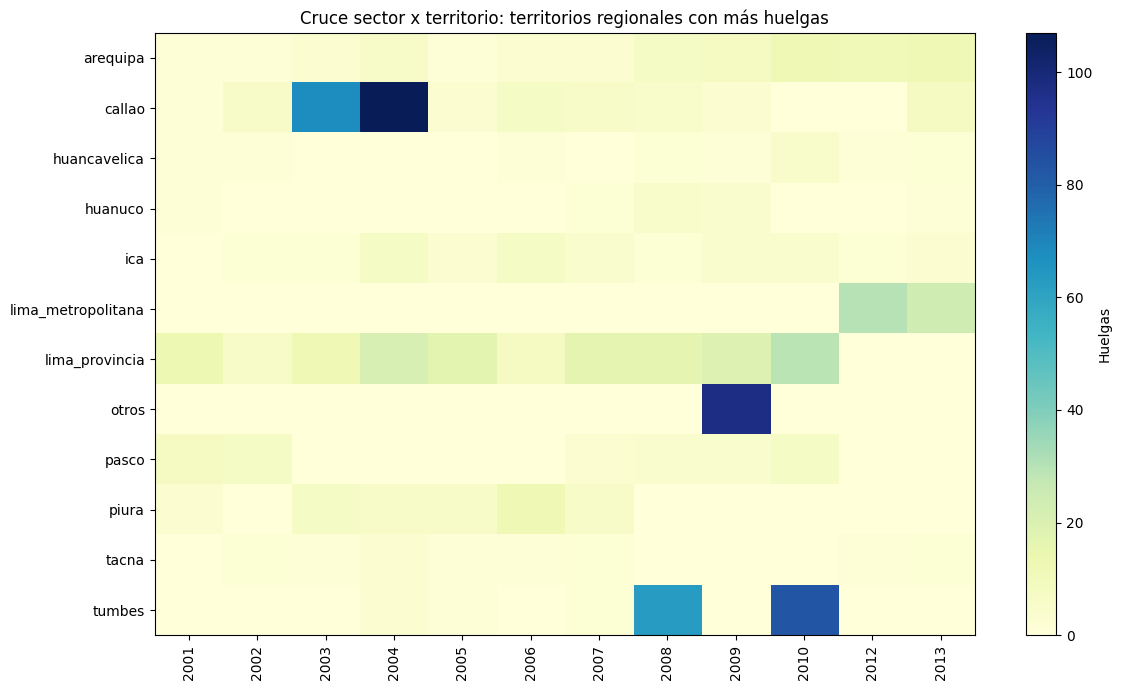

In [6]:
plt.figure(figsize=(12, 7))
plt.imshow(pivot_territory.T, aspect='auto', cmap='YlGnBu')
plt.colorbar(label='Huelgas')
plt.yticks(range(len(pivot_territory.columns)), pivot_territory.columns)
plt.xticks(range(len(pivot_territory.index)), pivot_territory.index, rotation=90)
plt.title('Cruce sector x territorio: territorios regionales con más huelgas')
plt.tight_layout()
plt.show()

## Sectores con más huelgas


In [7]:
top_sectors = (
    cross.groupby('actividad_homologada_agregada', dropna=False)['huelgas']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)
pivot_sector = (
    cross[cross['actividad_homologada_agregada'].isin(top_sectors)]
    .groupby(['anio', 'actividad_homologada_agregada'], dropna=False)['huelgas']
    .sum()
    .reset_index()
    .pivot(index='anio', columns='actividad_homologada_agregada', values='huelgas')
    .fillna(0)
)
pivot_sector.head()

actividad_homologada_agregada,adm_publica,administra_publica_y_defensa,comercio,construccion,electricidad_agua,inmobiliario,manufactura,mineria,salud_social,transporte
anio,,,,,,,,,,
2001,0.0,2.0,0.0,0.0,0.0,2.0,0.0,30.0,0.0,0.0
2002,0.0,2.0,0.0,0.0,8.0,18.0,0.0,40.0,2.0,22.0
2003,0.0,14.0,4.0,12.0,19.0,8.0,56.0,9.0,6.0,20.0
2004,0.0,26.0,0.0,10.0,32.0,4.0,48.0,42.0,12.0,20.0
2005,0.0,12.0,0.0,8.0,28.0,4.0,14.0,23.0,18.0,14.0


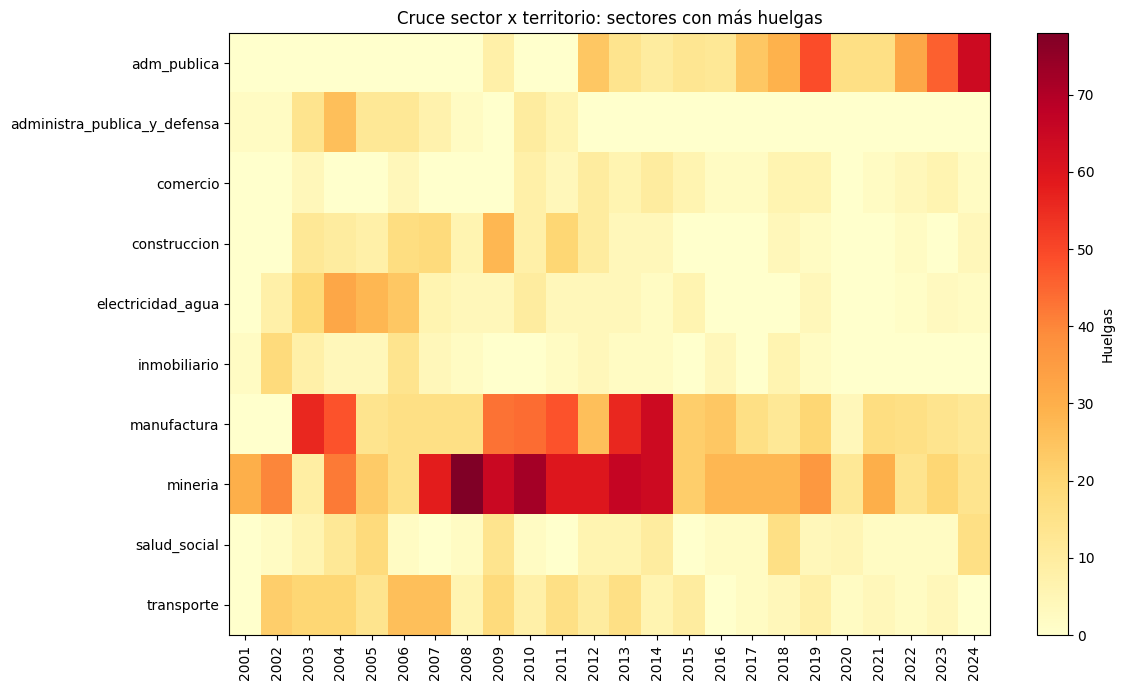

In [8]:
plt.figure(figsize=(12, 7))
plt.imshow(pivot_sector.T, aspect='auto', cmap='YlOrRd')
plt.colorbar(label='Huelgas')
plt.yticks(range(len(pivot_sector.columns)), pivot_sector.columns)
plt.xticks(range(len(pivot_sector.index)), pivot_sector.index, rotation=90)
plt.title('Cruce sector x territorio: sectores con más huelgas')
plt.tight_layout()
plt.show()

## Casos con discrepancia de validación

Esta tabla ayuda a revisar manualmente los años y territorios que todavía no cierran exactamente con el total del cuadro fuente.


In [9]:
validation[validation['estado'] == 'revisar'].sort_values(['anio', 'territorio_original', 'metrica'])

,anio,hoja_excel,territorio_original,territorio_homologado_agregado,nivel_territorial,metrica,total_extraido,total_fuente,diferencia,estado
77,2002,C-11,AREQUIPA,arequipa,regional,horas_hombre_perdidas,40832.0,58960.0,-18128.0,revisar
75,2002,C-11,AREQUIPA,arequipa,regional,huelgas,1.0,4.0,-3.0,revisar
76,2002,C-11,AREQUIPA,arequipa,regional,trabajadores_comprendidos,882.0,3148.0,-2266.0,revisar
146,2002,C-11,HUACHO,huacho,zona,horas_hombre_perdidas,894520.0,912648.0,-18128.0,revisar
144,2002,C-11,HUACHO,huacho,zona,huelgas,61.0,64.0,-3.0,revisar
145,2002,C-11,HUACHO,huacho,zona,trabajadores_comprendidos,20659.0,22925.0,-2266.0,revisar
641,2009,C-11,HUACHO,huacho,zona,horas_hombre_perdidas,0.0,2128.0,-2128.0,revisar
639,2009,C-11,HUACHO,huacho,zona,huelgas,0.0,1.0,-1.0,revisar
640,2009,C-11,HUACHO,huacho,zona,trabajadores_comprendidos,0.0,38.0,-38.0,revisar
686,2009,C-11,OTROS *,otros,regional,horas_hombre_perdidas,1436674.0,1452466.0,-15792.0,revisar


## Sector dominante por territorio regional

Este bloque resume, para cada territorio regional, qué sector acumula más huelgas a lo largo del período observado. Se usa solo `nivel_territorial = regional` para no mezclar regiones con zonas.


In [10]:
regional = cross[cross['nivel_territorial'] == 'regional'].copy()
regional = regional[regional['huelgas'].fillna(0) > 0].copy()

territorio_sector = (
    regional.groupby(['territorio_homologado_agregado', 'actividad_homologada_agregada'], as_index=False)[['huelgas', 'trabajadores_comprendidos', 'horas_hombre_perdidas']]
    .sum()
)

territorio_totales = (
    territorio_sector.groupby('territorio_homologado_agregado', as_index=False)['huelgas']
    .sum()
    .rename(columns={'huelgas': 'huelgas_totales_territorio'})
)

territorio_sector = territorio_sector.merge(territorio_totales, on='territorio_homologado_agregado', how='left')
territorio_sector['participacion_huelgas'] = territorio_sector['huelgas'] / territorio_sector['huelgas_totales_territorio']

sector_dominante = (
    territorio_sector.sort_values(['territorio_homologado_agregado', 'huelgas'], ascending=[True, False])
    .groupby('territorio_homologado_agregado')
    .head(1)
    .sort_values('huelgas_totales_territorio', ascending=False)
    .reset_index(drop=True)
)

sector_dominante[['territorio_homologado_agregado', 'actividad_homologada_agregada', 'huelgas', 'huelgas_totales_territorio', 'participacion_huelgas']].head(20)


,territorio_homologado_agregado,actividad_homologada_agregada,huelgas,huelgas_totales_territorio,participacion_huelgas
0,callao,transporte,56.0,214.0,0.261682
1,lima_provincia,manufactura,46.0,157.0,0.292994
2,tumbes,mineria,75.0,152.0,0.493421
3,otros,mineria,33.0,97.0,0.340206
4,arequipa,mineria,23.0,68.0,0.338235
5,lima_metropolitana,manufactura,12.0,54.0,0.222222
6,piura,electricidad_agua,11.0,40.0,0.275000
7,ica,mineria,24.0,40.0,0.600000
8,pasco,mineria,32.0,33.0,0.969697
9,huancavelica,mineria,12.0,14.0,0.857143


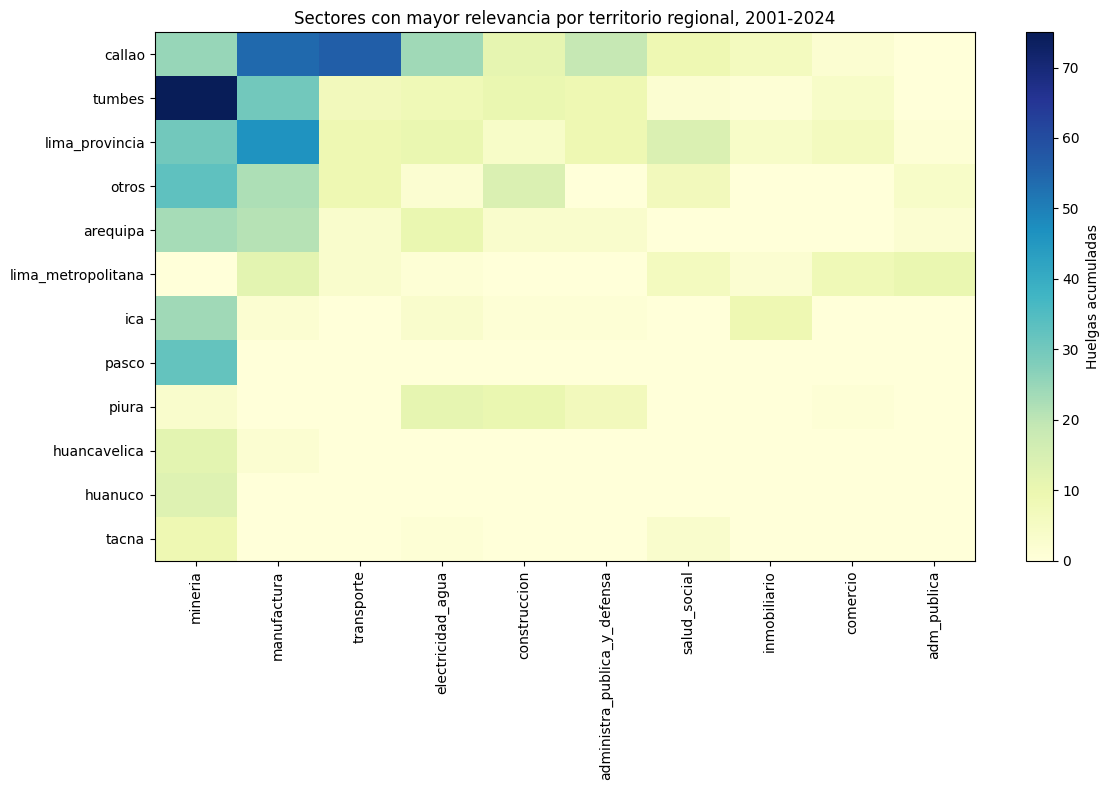

In [11]:
top_territorios = territorio_totales.sort_values('huelgas_totales_territorio', ascending=False).head(12)['territorio_homologado_agregado']
top_sectores = (
    territorio_sector.groupby('actividad_homologada_agregada', as_index=False)['huelgas']
    .sum()
    .sort_values('huelgas', ascending=False)
    .head(10)['actividad_homologada_agregada']
)

heat = (
    territorio_sector[
        territorio_sector['territorio_homologado_agregado'].isin(top_territorios)
        & territorio_sector['actividad_homologada_agregada'].isin(top_sectores)
    ]
    .pivot(index='territorio_homologado_agregado', columns='actividad_homologada_agregada', values='huelgas')
    .fillna(0)
)

heat = heat.loc[heat.sum(axis=1).sort_values(ascending=False).index, heat.sum(axis=0).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(heat.values, aspect='auto', cmap='YlGnBu')
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=90)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_title('Sectores con mayor relevancia por territorio regional, 2001-2024')
fig.colorbar(im, ax=ax, label='Huelgas acumuladas')
plt.tight_layout()
plt.show()
